# Lab 5 — Trace an MLP forward pass

In this lab, every large-looking neural network will be built from two
small NumPy operations:

> weighted sum + bias → ReLU

**Run it:** upload this notebook to Google Colab, or follow the short
[setup guide](../../week02/SETUP.md). It uses only **NumPy**,
**Matplotlib**, and **scikit-learn**.

Complete each TODO, then run the check directly below it.

By the end, you will be able to:

- calculate one neuron by hand;
- calculate a whole layer with matrices;
- trace a two-hidden-layer MLP from inputs to class scores;
- write the same forward pass in NumPy;
- train a digit MLP and verify one library prediction manually.

## Goal and workflow

For every task, follow the same routine:

1. **Predict** the answer on paper.
2. **Code** the calculation.
3. **Check** the shape and values.
4. **Explain** what each result means.

The first two examples include click-to-reveal answers. The changed MLP
exercise is yours to complete before opening the solution notebook.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

np.set_printoptions(precision=3, suppress=True)
BLUE = "#2563EB"
ORANGE = "#F97316"

print("NumPy version:", np.__version__)
print("Ready for Lab 5")

NumPy version: 2.0.2
Ready for Lab 5


In [2]:
# Visualization helper: you do not need to understand this plotting code yet.
def show_digit_grid(images, labels, predictions=None, columns=6):
    rows = int(np.ceil(len(images) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(1.8 * columns, 1.9 * rows))
    axes = np.atleast_1d(axes).ravel()

    for index, ax in enumerate(axes):
        ax.axis("off")
        if index >= len(images):
            continue
        ax.imshow(images[index], cmap="gray_r")
        if predictions is None:
            ax.set_title(f"label: {labels[index]}")
        else:
            correct = predictions[index] == labels[index]
            color = BLUE if correct else ORANGE
            ax.set_title(
                f"true {labels[index]} | pred {predictions[index]}",
                color=color,
                fontsize=9,
            )

    plt.tight_layout()
    plt.show()

## Part 1 — One artificial neuron

A neuron receives inputs, multiplies each input by a weight, adds the
results, and adds a bias:

$$z=x\cdot w+b.$$

ReLU is a simple activation:

$$\operatorname{ReLU}(z)=\max(0,z).$$

**Parameters** are the values training can change: the weights and bias.
Inputs come from the data.

**Worked example 1.** For `x = [2, -1]`, `w = [3, 2]`, and `b = 1`,
calculate the score and ReLU output.

<details><summary>Click for answer</summary>

`score = 2(3) + (-1)(2) + 1 = 5`. Because 5 is positive,
`ReLU(5) = 5`.

</details>

In [3]:
# Validate worked example 1 after doing it on paper.
example_input = np.array([2, -1])
example_weights = np.array([3, 2])
example_bias = 1

example_score = example_input @ example_weights + example_bias
example_output = np.maximum(0, example_score)

print("score:", example_score)
print("ReLU output:", example_output)

score: 5
ReLU output: 5


### Task 1 — change one parameter

Keep the same input and weights, but change the bias from `1` to `-6`.

1. Predict the new score.
2. Predict the ReLU output.
3. Enter both answers below.

In [4]:
# TODO 1: replace None with your two answers.
changed_score = None
changed_output = None

In [5]:
if changed_score is None or changed_output is None:
    print("Complete Task 1, then run this check again.")
else:
    assert changed_score == -2
    assert changed_output == 0
    print("new score:", changed_score)
    print("new ReLU output:", changed_output)
    print("✓ Changing a parameter changed the neuron's output")

Complete Task 1, then run this check again.


**Explain it.** Which number changed: an input or a parameter? How did
that change affect the result? Write one sentence.

## Part 2 — A layer is several neurons together

A dense layer calculates all examples and neurons at once:

$$Z=XW+b.$$

- Rows of `X` are examples.
- Columns of `X` are input features.
- Columns of `W` belong to different neurons.
- `b` contains one bias per neuron.

**Worked example 2.** If `X` has shape `(2, 2)` and `W` has shape
`(2, 3)`, what shape does `X @ W` have?

<details><summary>Click for answer</summary>

`(2, 3)`: two examples leave the layer with three neuron values each.

</details>

### Task 2 — implement the two reusable building blocks

Complete `dense` and `relu`. These functions should work for one value,
one example, or a matrix of examples.

In [6]:
# TODO 2
def dense(inputs, weights, bias):
    # Calculate inputs @ weights + bias.
    return None


def relu(values):
    # Keep positive values and replace negative values with zero.
    return None

In [7]:
dense_test = dense(np.array([1, 2]), np.array([1, 2]), 0)
relu_test = relu(np.array([-3, 0, 4]))

if dense_test is None or relu_test is None:
    print("Complete Task 2, then run this check again.")
else:
    assert dense_test == 5
    assert np.array_equal(relu_test, np.array([0, 0, 4]))
    print("dense test:", dense_test)
    print("ReLU test:", relu_test)
    print("✓ Both building blocks work")

Complete Task 2, then run this check again.


### Task 3 — calculate one complete hidden layer

This exercise uses new, small integer values. Calculate `Z1` and `H1`
on paper first, then write the matching NumPy lines.

Predict the shape before running the cell.

In [8]:
X_practice = np.array([
    [ 1, -1],
    [-1,  2],
])

W1_practice = np.array([
    [1,  2, -1],
    [2, -1,  1],
])
b1_practice = np.array([0, 1, 0])

print("X shape: ", X_practice.shape)
print("W1 shape:", W1_practice.shape)
print("b1 shape:", b1_practice.shape)

X shape:  (2, 2)
W1 shape: (2, 3)
b1 shape: (3,)


In [9]:
# TODO 3: use dense, then ReLU.
Z1_practice = None
H1_practice = None

In [10]:
if Z1_practice is None or H1_practice is None:
    print("Complete Task 3, then run this check again.")
else:
    expected_Z1 = np.array([[-1, 4, -2], [3, -3, 3]])
    expected_H1 = np.array([[0, 4, 0], [3, 0, 3]])
    assert np.array_equal(Z1_practice, expected_Z1)
    assert np.array_equal(H1_practice, expected_H1)
    print("Z1 before ReLU:\n", Z1_practice)
    print("H1 after ReLU:\n", H1_practice)
    print("✓ First hidden layer is correct")

Complete Task 3, then run this check again.


**Explain it.** In `H1`, what does one row represent? What does one
column represent?

## Part 3 — Trace a complete two-hidden-layer MLP

We now continue the changed example:

> `X → Z1 → H1 → Z2 → H2 → scores → predicted class`

The network has `2 → 3 → 2 → 2` values. Nothing new is added: each
hidden layer repeats `dense`, then `relu`.

In [11]:
W2_practice = np.array([
    [1,  0],
    [1, -1],
    [0,  1],
])
b2_practice = np.array([0, 0])

W3_practice = np.array([
    [ 1, -1],
    [-1,  2],
])
b3_practice = np.array([0, 0])

print("Layer widths: 2 inputs → 3 neurons → 2 neurons → 2 scores")

Layer widths: 2 inputs → 3 neurons → 2 neurons → 2 scores


### Task 4 — finish the forward pass by hand and in code

Before coding, calculate these values on paper:

1. `Z2 = H1 @ W2 + b2`
2. `H2 = ReLU(Z2)`
3. `scores = H2 @ W3 + b3`
4. the predicted class for each row (`argmax`)

Then complete the function. Do not open the solution notebook until your
shapes and values pass the check.

In [12]:
# TODO 4
def two_hidden_layer_forward(inputs, W1, b1, W2, b2, W3, b3):
    Z1 = None
    H1 = None
    Z2 = None
    H2 = None
    scores = None
    return Z1, H1, Z2, H2, scores

In [13]:
forward_results = two_hidden_layer_forward(
    X_practice,
    W1_practice,
    b1_practice,
    W2_practice,
    b2_practice,
    W3_practice,
    b3_practice,
)

if forward_results[-1] is None:
    print("Complete Task 4, then run this check again.")
else:
    Z1_check, H1_check, Z2_check, H2_check, scores_check = forward_results
    predictions_check = np.argmax(scores_check, axis=1)

    assert np.array_equal(Z2_check, np.array([[4, -4], [3, 3]]))
    assert np.array_equal(H2_check, np.array([[4, 0], [3, 3]]))
    assert np.array_equal(scores_check, np.array([[4, -4], [0, 3]]))
    assert np.array_equal(predictions_check, np.array([0, 1]))

    print("Z1:\n", Z1_check)
    print("H1:\n", H1_check)
    print("Z2:\n", Z2_check)
    print("H2:\n", H2_check)
    print("scores:\n", scores_check)
    print("predicted classes:", predictions_check)
    print("✓ Complete forward pass is correct")

Complete Task 4, then run this check again.


**Explain it.** Which operation created the class scores? Did this
forward pass learn or change any parameter?

### Interactive pause

Open [Google's nodes and hidden-layers interactive](https://developers.google.com/machine-learning/crash-course/neural-networks/nodes-hidden-layers).

- Predict the output before pressing play.
- Change exactly one input, weight, or bias.
- Identify every later value that changes.
- Add a hidden layer and trace one path from input to output.

Optional: use [TensorFlow Playground](https://playground.tensorflow.org/)
to inspect how several hidden neurons pass information forward.

## Part 4 — Scale the same idea to handwritten digits

A digit image is an `8 × 8` grid. Flattening it gives 64 input numbers.
The MLP will use this shape:

> `64 inputs → 32 neurons → 16 neurons → 10 class scores`

The dataset is built into scikit-learn, so no file or internet download
is required.

image shape: (8, 8)
data-matrix shape: (1797, 64)
label shape: (1797,)


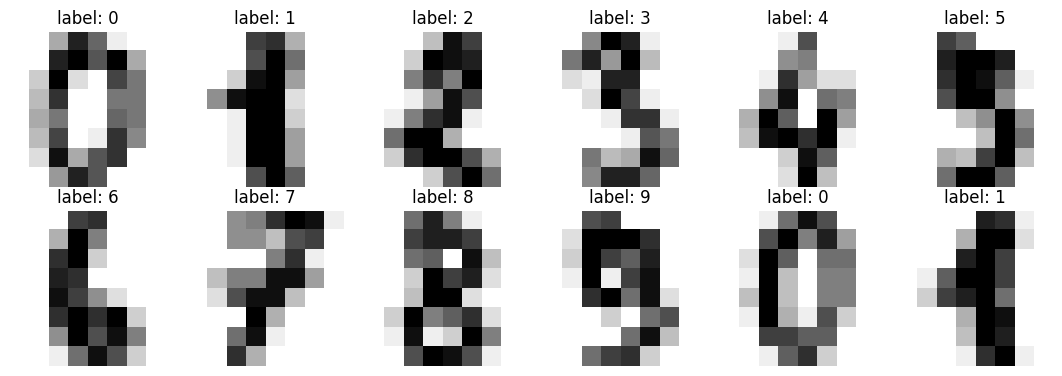

In [14]:
digits = load_digits()

print("image shape:", digits.images[0].shape)
print("data-matrix shape:", digits.data.shape)
print("label shape:", digits.target.shape)

show_digit_grid(digits.images[:12], digits.target[:12])

### Task 5 — prepare the data

Create:

- `X_digits`: the flattened pixel matrix divided by `16.0`;
- `y_digits`: the digit labels;
- an 80% training and 20% test split.

Normalizing changes pixel values from `0...16` to `0...1`.

In [15]:
# TODO 5
X_digits = None
y_digits = None

X_train = None
X_test = None
y_train = None
y_test = None

In [16]:
if X_train is None:
    print("Complete Task 5, then run this check again.")
else:
    assert X_train.shape[1] == 64
    assert X_test.shape[0] == 360
    assert X_train.min() >= 0 and X_train.max() <= 1
    assert set(np.unique(y_train)) == set(range(10))
    print("training matrix:", X_train.shape)
    print("test matrix:    ", X_test.shape)
    print("pixel range:    ", X_train.min(), "to", X_train.max())
    print("✓ Data is ready")

Complete Task 5, then run this check again.


### Task 6 — define, fit, and test the MLP

Use `MLPClassifier` with two hidden layers, 32 and 16 neurons.

- `fit` learns weights and biases from the training data.
- `predict` performs forward passes using the learned parameters.
- `score` reports the fraction of correct test predictions.

In [17]:
# TODO 6: create the model, fit it, and make test predictions.
digit_model = None
digit_predictions = None
test_accuracy = None

In [18]:
if digit_model is None or digit_predictions is None:
    print("Complete Task 6, then run this check again.")
else:
    assert len(digit_model.coefs_) == 3
    assert digit_predictions.shape == y_test.shape
    assert test_accuracy > 0.90
    print(f"test accuracy: {test_accuracy:.3f}")
    print("weight shapes:", [weights.shape for weights in digit_model.coefs_])
    print("bias shapes:  ", [bias.shape for bias in digit_model.intercepts_])
    show_digit_grid(
        X_test[:12].reshape(-1, 8, 8),
        y_test[:12],
        digit_predictions[:12],
    )
    print("✓ The digit MLP is trained")

Complete Task 6, then run this check again.


**Explain it.** Match these shapes to the architecture:
`(64, 32)`, `(32, 16)`, and `(16, 10)`.

## Part 5 — verify one library prediction with NumPy

The library stores its learned weights in `digit_model.coefs_` and its
biases in `digit_model.intercepts_`. We can apply the same forward-pass
equations ourselves.

Softmax turns the final ten scores into probabilities that sum to one:

$$\operatorname{softmax}(s_i)=\frac{e^{s_i}}{\sum_j e^{s_j}}.$$

In [19]:
def softmax(scores):
    shifted_scores = scores - np.max(scores, axis=1, keepdims=True)
    exponentials = np.exp(shifted_scores)
    return exponentials / exponentials.sum(axis=1, keepdims=True)

### Task 7 — reproduce `predict_proba`

Complete the three dense calculations and the two ReLUs. Return the
softmax probabilities. Keep the sample as a row matrix with shape
`(1, 64)`.

In [20]:
# TODO 7
def manual_predict_proba(sample, model):
    W1, W2, W3 = model.coefs_
    b1, b2, b3 = model.intercepts_

    H1 = None
    H2 = None
    scores = None
    return None

In [21]:
if digit_model is None:
    print("Complete Task 6 before checking Task 7.")
else:
    one_sample = X_test[:1]
    manual_probabilities = manual_predict_proba(one_sample, digit_model)

    if manual_probabilities is None:
        print("Complete Task 7, then run this check again.")
    else:
        library_probabilities = digit_model.predict_proba(one_sample)
        assert np.allclose(manual_probabilities, library_probabilities)

        print("manual probabilities:\n", manual_probabilities)
        print("library probabilities:\n", library_probabilities)
        print("manual class:", np.argmax(manual_probabilities, axis=1)[0])
        print("library class:", digit_model.predict(one_sample)[0])
        print("✓ NumPy and scikit-learn agree")

Complete Task 6 before checking Task 7.


## Final check

Without looking back, answer:

1. What does one neuron calculate before ReLU?
2. Which values are parameters?
3. Why do weight-matrix columns correspond to neurons?
4. What does ReLU change?
5. Write the complete forward-pass chain.
6. What is the difference between `fit` and `predict`?

Then draw the shape chain `64 → 32 → 16 → 10` and label every
weight matrix.

## Optional challenge

Change exactly one thing and predict the effect before rerunning:

- replace `(32, 16)` with `(16, 8)`;
- inspect one incorrectly classified digit;
- change one tiny-model weight and trace every downstream value;
- print the shape after every layer in `manual_predict_proba`.

The key idea remains unchanged: a large MLP repeats the same small
forward-pass operations many times.